# Credit Card Fraud Detection Analysis
Author: Devon Wildman

This project explores credit card transaction data to detect fraudulent activity using data analysis and machine learning.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("creditcard.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

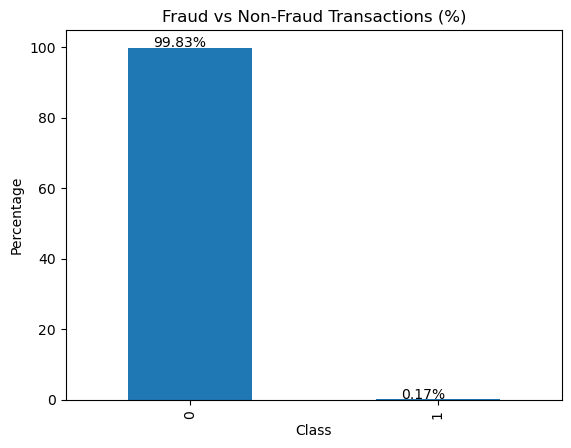

In [5]:
ax = (df['Class'].value_counts(normalize=True) * 100).plot(kind='bar')

for i in ax.patches:
    ax.text(i.get_x() + 0.1, i.get_height() + 0.2, f"{i.get_height():.2f}%", fontsize=10)

plt.title("Fraud vs Non-Fraud Transactions (%)")
plt.xlabel("Class")
plt.ylabel("Percentage")

plt.show()

Fraudulent transactions have a higher average transaction amount compared to normal transactions. This suggests that unusually large transactions may be a strong indicator of fraudulent activity.

## Average Transaction Amount (Fraud vs Normal)

In [8]:
df.groupby('Class')['Amount'].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

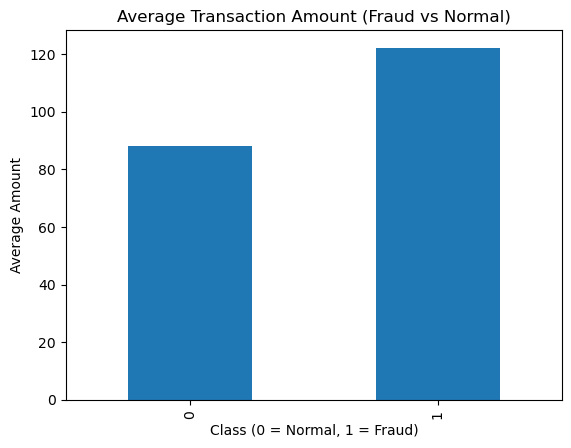

In [9]:
import matplotlib.pyplot as plt

df.groupby('Class')['Amount'].mean().plot(kind='bar')

plt.title("Average Transaction Amount (Fraud vs Normal)")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Average Amount")

plt.show()

Fraudulent transactions have a higher average transaction amount compared to normal transactions, suggesting that unusually large transactions may indicate potential fraud.

## Correlation Heatmap (Feature Relationships)

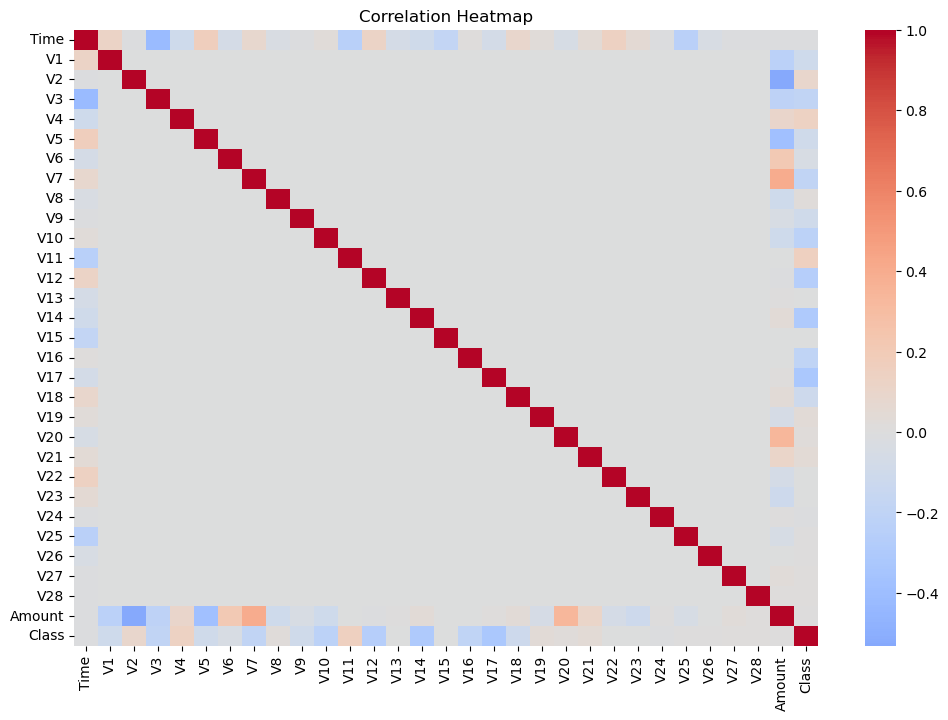

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create correlation matrix
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0)

plt.title("Correlation Heatmap")
plt.show()

### Insight

The correlation heatmap shows relationships between features in the dataset. 
Most features are weakly correlated, which is expected due to anonymisation (V1–V28).

However, certain features show slight correlations with the target variable (Class), 
which may help identify patterns associated with fraudulent transactions.

These relationships can be useful for building predictive fraud detection models.

### Top Correlations with Fraud

In [15]:
df.corr()['Class'].sort_values(ascending=False).head(10)

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

### Insight

This output shows which features have the strongest relationship with fraudulent transactions.

Features with higher positive or negative correlation with the target variable (Class) 
may be useful predictors in a fraud detection model.

## Fraud Detection Model

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56849    15]
 [   31    67]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.68      0.74        98

    accuracy                           1.00     56962
   macro avg       0.91      0.84      0.87     56962
weighted avg       1.00      1.00      1.00     56962



### Insight

The model was trained to classify fraudulent and non-fraudulent transactions.

Due to the highly imbalanced dataset, the model performs well on normal transactions 
but may struggle to detect fraud cases.

Metrics such as recall and precision are more important than accuracy in this context.

## Model Evaluation – Confusion Matrix

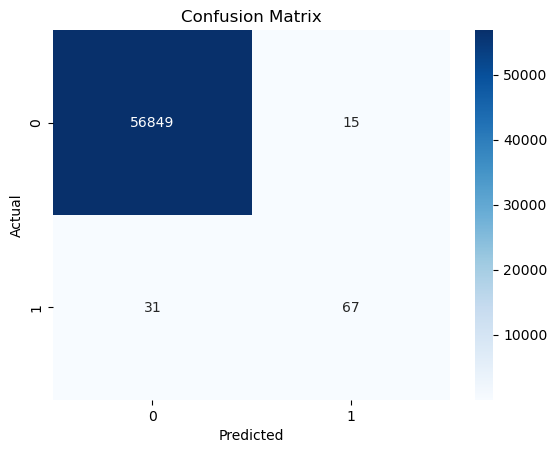

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 🔍 Analysis

The model demonstrates strong performance in identifying non-fraudulent transactions, achieving near-perfect precision for the majority class.

However, performance on fraudulent transactions is lower, particularly in recall. This indicates that some fraud cases are not being detected.

This is expected due to the highly imbalanced dataset, where fraudulent transactions represent a very small proportion of the data.

In fraud detection, recall is especially important, as missing fraudulent transactions can have significant financial consequences.




## Final Conclusion

This project analysed credit card transactions to identify patterns associated with fraudulent activity.

Key findings:
- Fraudulent transactions are extremely rare, creating a highly imbalanced dataset
- Fraud cases show different transaction behaviours compared to normal transactions
- Certain features exhibit correlations that may help detect fraud

A machine learning model was developed to classify transactions, demonstrating the challenges of detecting fraud in imbalanced datasets.

Future improvements could include advanced models and techniques to improve fraud detection performance.

This project highlights the importance of handling class imbalance in real-world machine learning problems, particularly in fraud detection systems.

Techniques such as SMOTE, undersampling, or ensemble models could be applied to improve detection of fraudulent transactions.